In [1]:
import random
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist


Data Preparation - The Data is loaded into Training & Testing dataset using load_data() method

In [3]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

The data is anlaysed using .shape method where the number of images and image pixels count in training & testing dataset are displayed as below

In [ ]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape 

#x_train dataset has 60000 images of size 28 X 28
#x_test dataset has 10000 images of size 28 X 28

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [5]:
def category(x):
    category_list = ['T-shirt / Top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle Boot']
    return category_list[x] 

Below block of code displays 5 sample images from Training dataset along with their category label (name)

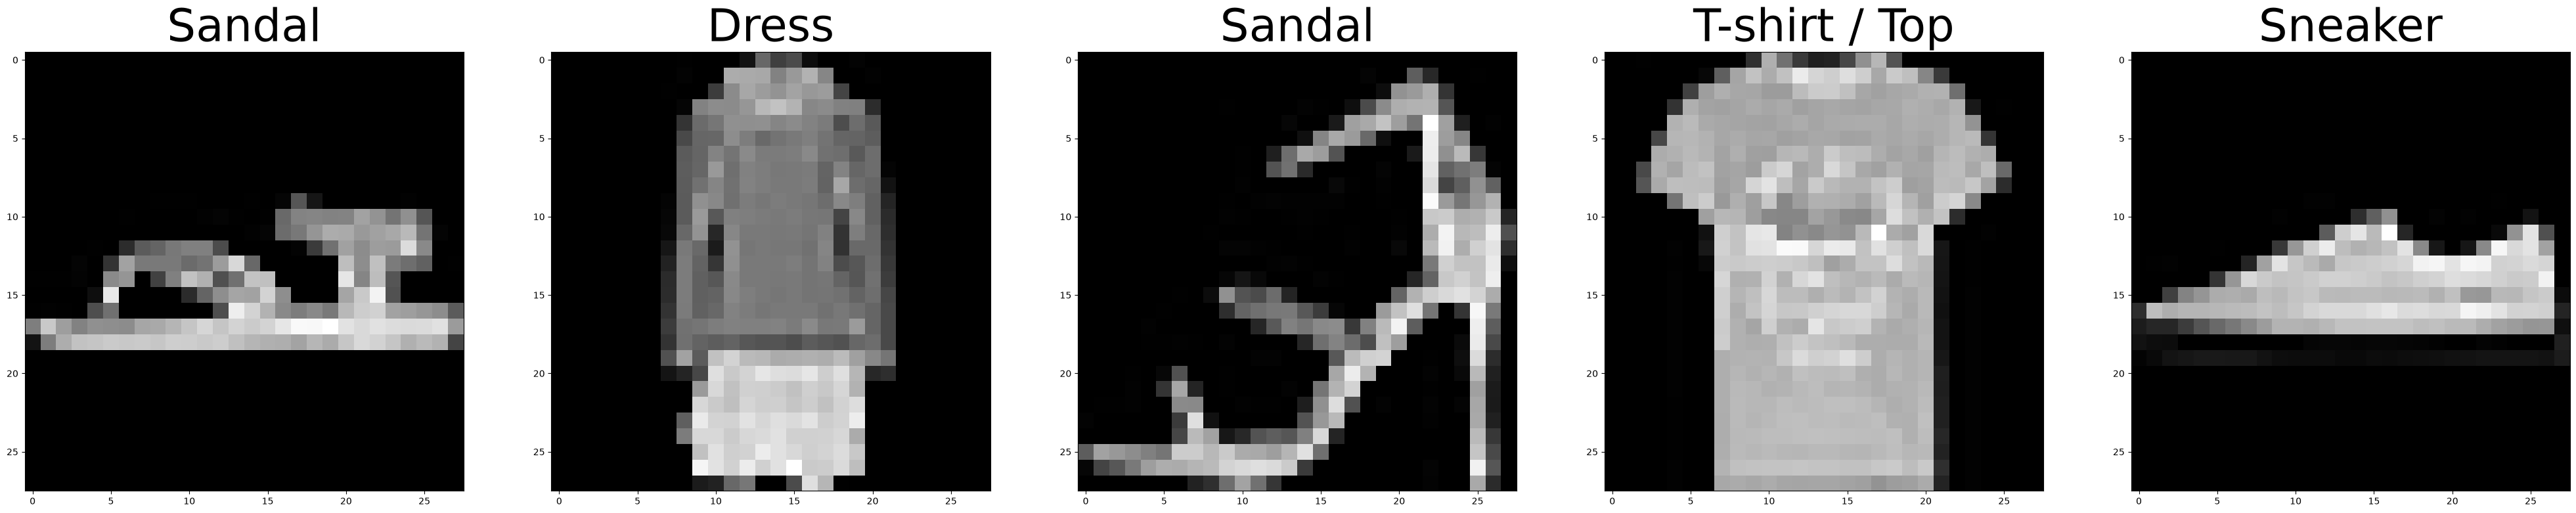

In [20]:
start = random.randint(0,60000)
end = start + 5
plt.figure(figsize=(50,50))
for i, item in enumerate(range(start, end, 1)):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[item],cmap='gray')
    plt.title(category(y_train[item]), fontsize=50)
    plt.show

y_train & y_test dataset are array which contains labels and can be viewed as below 

In [7]:
y_train[0:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

x_train & x_test dataset are normalized as below

In [8]:
x_train_normalized = x_train.astype(float)/255.0
x_test_normalized = x_test.astype(float)/255.0

In [9]:
x_train_normalized[233]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.00392157,
        0.00392157, 0.        , 0.01960784, 0.38431373, 0.45882353,
        0.35294118, 0.    

Building a CNN Model 

The CNN models is efficient for handling image data which are 2D in nature. 

Convolution Layer - 

The images are processed using Convolution layers which run filters of reduced pixels dimension over the input image and generate a feature map after identifying all the important features of the image.

MaxPool Layer - 

The feature map generated by the convoluated layer is provied as input to MaxPool layer which retains the features of the maximum weightage and generate a reduced pixel dimension of the image without impacting the image content or features.

Flatten Layer - 

The flatten layer converts the 2-Dimension nature of the image into 1-Dimension array which can be provided as input to hidden layer of the deep learning model

Hidden Layers - 

The hidden layer make use of a set of neurons along with 'relu' activation function to identify pattern of the input array. Multiple hidden layers can be used if required based on the complexity of the images being processed.

Output Layer - 

The final output is generated using Output layer which makes use of 'softmax' activation function. As the model is classifying images across 10 different labels, 10 neurons are used in the output layer.




In [ ]:
model = models.Sequential([
    layers.Input(shape=(28,28,1),name='Input_Layer'),
    layers.Conv2D(filters=16,kernel_size=(3,3),activation='relu',name='Convolution_Layer_1'), 
    #Convolution_Layer_1 will generate a convulated output of dimension 28-3+1 = 26 => [26,26] 
    layers.MaxPool2D(pool_size=(2,2),name='MaxPool_Layer_1'),
    #Pooling Layer 1 will generate a output dimension of 26/2 = 13 => [13,13,16]
    layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',name='Convolution_Layer_2'),
    #Convolution Layer 2 will generate a convulated output of dimension 13-3+1 = 11 => [11,11]
    layers.MaxPool2D(pool_size=(2,2),name='MaxPool_Layer_2'),
    #Pooling Layer 2 will generate an output of dimension 11/2 = 5.5 => [5.5,5.5,32]
    layers.Flatten(name='Flatten_Layer'),
    layers.Dense(16,activation='relu',name='Hidden_Layer_1'),
    layers.Dense(32,activation='relu',name='Hidden_Layer_2'),
    layers.Dense(10,activation='softmax',name='Output_Layer')
])

The CNN model is complied using 'Adam' optimizer and sparse_categorical_crossentropy loss function and is measured using 'Accuracy' metric

In [11]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

The number of epochs to be used for training the CNN model is identified using EarlyStopping function available with keras.callbacks library. This function keeps a track of loss function value and stop the training iteration once the loss function hits the mininum value.

In [12]:
from keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='loss', mode='min', verbose=1)

The training history can be seen below where the accuracy of around 95% is achieved by training the model for 34 epochs

In [13]:
model.fit(x_train_normalized,y_train,epochs=200,callbacks=[es])

Epoch 1/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.7760 - loss: 0.6048
Epoch 2/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8571 - loss: 0.3982
Epoch 3/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8748 - loss: 0.3475
Epoch 4/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8841 - loss: 0.3158
Epoch 5/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8935 - loss: 0.2902
Epoch 6/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9006 - loss: 0.2711
Epoch 7/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9075 - loss: 0.2541
Epoch 8/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9106 - loss: 0.2437
Epoch 9/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9158 - loss: 0.2298
Epoch 10/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9177 - loss: 0.2224
Epoch 11/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9209 - loss: 0.2126
Epoch 12/200


Model Evaluation - 

The accuracy of around 90% is achieved when the model is evaluated with test dataset.

In [14]:
test_loss, test_accuracy = model.evaluate(x_test_normalized, y_test )

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8996 - loss: 0.3325


Below output of code block displays the model predication for 10 sample images from the test dataset along with their actual value in the test dataset.

In [15]:
for i in range(10):
    num = random.randint(0,10000)
    start = num
    end = num + 1   
    prediction = model.predict(x_test_normalized[start:end])
    prediction_digit = np.argmax(prediction)    
    print(f'The actual image at index {num} is {category(y_test[num])} and Prediction for this image is {category(prediction_digit)}')



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
The actual image at index 6021 is Trouser and Prediction for this image is Trouser
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
The actual image at index 8658 is Shirt and Prediction for this image is Coat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
The actual image at index 7844 is Sandal and Prediction for this image is Sandal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
The actual image at index 9565 is Dress and Prediction for this image is Dress
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
The actual image at index 708 is Bag and Prediction for this image is Bag
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
The actual image at index 3093 is Bag and Prediction for this image is Bag
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
The actual image at index 6870 is Shirt and Prediction for this image is Shirt
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
The actual image at index 7515 is Bag and Prediction for this image is Bag
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
The actual image at index 9759 is

To generate a confusion matrix, the predicated values of all 10000 images in the test dataset is stored in an array using below code block

In [16]:
prediction_list = []
for i in range(10000):
    prediction = model.predict(x_test_normalized[i:i+1])
    prediction_digit = np.argmax(prediction)
    prediction_list.append(prediction_digit)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━

The confusion matrix is created using y_test array & prediction array created above 

In [17]:
cm = confusion_matrix(y_test, prediction_list)

In [18]:
category_list = ['T-shirt / Top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle Boot']

The confusion matrix is a 10 X 10 matrix as there are 10 different classification available. To understand the matrix better, a heatmap plot is created and is displayed below

<function matplotlib.pyplot.show(close=None, block=None)>

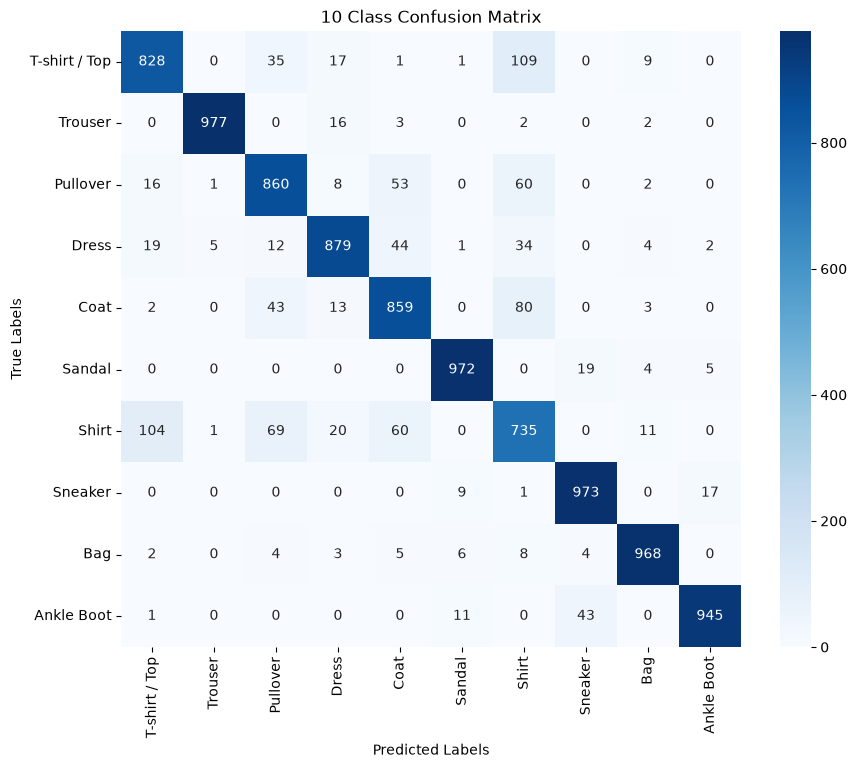

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap='Blues',annot=True, fmt='d', xticklabels=category_list, yticklabels=category_list)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title("10 Class Confusion Matrix")
plt.show

Model Analysis - 

Question 1 - 

Why are CNNs more suitable than Artificial Neural Networks (ANNs) for image 
classification?

Answer - 

CNN models are efficient in handling 2-Dimension image input by making use of Convolution & Pool process. The convolution & pool process identify the important features of the image along with reducing the pixel dimension. The reduced image is then convered into 1-Dimension array using flattening process. The 1-D array is the fed into ANN model kind of neural network to understand the image pattern and perform classification.

However, ANN models works directly with 1-Dimension array and would require large amount of processing power & complexity to process a 2-Dimension input and still would not be as efficient as CNN model.



Question 2 - 

What is the purpose of Convolution Layer?

Answer - 

The convolution layer is used to reduce the image size by eliminating the redundant part of the image and retaining only the important features of the image which need analysis. The convolution process makes use of filter which are of reduced pixel dimension as compared to the input image. The filter traverses over the image and identify the relevant features inorder to generate a feature map. 

This process helps in analysing the image quickly which incrases the overall efficiency & speed of the model.



Question 3 - 

Why is Max Pooling used in CNNs?  

Answer -

Max Pooling process further reduces the image dimension by retaining the features with maximum weightage only. The output of this process is an image which is drastically reduced in dimension but has got all the requried features which are required by subsequent layers of the model to understand hidden patterns.

Question 4 - 

Why is the Flatten layer required before the Dense layers?  

Answer - 

Flatten layer converts 2-Dimension image generated by pooling layer into 1-Dimension Array. This conversion is needed as the hidden layers of the neural network accept 1-Dimension array only as input.

Question 5- 

Why is the Softmax activation function used in the output layer?  

Answer - 

Softmax activation function is used for multi-class classification. As the input image can be classified across 10 different labels by the model, softmax activation is ideal to use for output calculation in this scenario.

Question 6 - 

How does the Adam optimizer help in training the CNN?

Answer - 

'Adam' optimizer combines the benefits of 'AdaGrad' & 'RMSProp' optimizer to achieve faster convergence & higher stability. Adam optimizer can adaptively adjust the learning rate for each individual weight and helps in better optimization of the model training process.